<a href="https://colab.research.google.com/github/Thanushi-Paranagama/ML-ASL-Hand-Sign-Recognition-System/blob/main/New_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# CELL 1: SETUP AND INSTALLATIONS
# =============================================================================

print("🤖 Improved ASL Hand Sign Recognition System - Overfitting Prevention")
print("=" * 70)

# Install required packages
!pip install kaggle tensorflow opencv-python matplotlib seaborn scikit-learn pillow

# Import libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files
import datetime
import json
import glob
from PIL import Image
import io

print(f"✅ Setup complete! Using TensorFlow {tf.__version__}")


🤖 Improved ASL Hand Sign Recognition System - Overfitting Prevention
✅ Setup complete! Using TensorFlow 2.19.0


In [2]:
# =============================================================================
# CELL 2: KAGGLE SETUP AND DATASET DOWNLOAD
# =============================================================================

print("\n📁 Step 1: Upload your kaggle.json file")
print("Click 'Choose Files' and select the kaggle.json you downloaded from Kaggle")

# Upload kaggle credentials
uploaded = files.upload()

# Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle credentials set up!")

# Test Kaggle connection
print("\n🔍 Testing Kaggle connection...")
!kaggle --version

print("\n⬇️ Downloading ASL dataset... (This takes 2-3 minutes)")

# Try multiple datasets until one works
datasets_to_try = [
    ("grassknoted/asl-alphabet", "asl-alphabet.zip"),
    ("debashishsau/aslamerican-sign-language-aplhabet-dataset", "aslamerican-sign-language-aplhabet-dataset.zip"),
    ("datamunge/sign-language-mnist", "sign-language-mnist.zip")
]

dataset_downloaded = False
dataset_info = None

for dataset_name, expected_zip in datasets_to_try:
    try:
        print(f"🔄 Trying {dataset_name}...")
        !kaggle datasets download -d {dataset_name}

        # Check if download succeeded
        zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]
        if zip_files:
            dataset_file = zip_files[0]
            dataset_info = (dataset_name, dataset_file)
            print(f"✅ Successfully downloaded: {dataset_file}")
            dataset_downloaded = True
            break
    except Exception as e:
        print(f"❌ Failed: {str(e)[:100]}")
        continue

if not dataset_downloaded:
    print("⚠️ All Kaggle downloads failed. Creating test dataset...")
    # Create a minimal test dataset
    for letter in ['A', 'B', 'C', 'D', 'E']:
        os.makedirs(f'asl_dataset/train/{letter}', exist_ok=True)
        for i in range(30):  # More test images
            !wget -q -O asl_dataset/train/{letter}/sample_{i}.jpg "https://via.placeholder.com/224x224/{letter}0{letter}0{letter}0/FFFFFF?text={letter}"

    print("✅ Created test dataset with A, B, C, D, E signs")
    dataset_info = ("test_dataset", "none")
    dataset_downloaded = True



📁 Step 1: Upload your kaggle.json file
Click 'Choose Files' and select the kaggle.json you downloaded from Kaggle


Saving kaggle.json to kaggle.json
✅ Kaggle credentials set up!

🔍 Testing Kaggle connection...
Kaggle API 1.7.4.5

⬇️ Downloading ASL dataset... (This takes 2-3 minutes)
🔄 Trying grassknoted/asl-alphabet...
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
 98% 1.00G/1.03G [00:01<00:00, 698MB/s]
100% 1.03G/1.03G [00:01<00:00, 897MB/s]
✅ Successfully downloaded: asl-alphabet.zip


In [3]:
# =============================================================================
# CELL 3: DATASET EXTRACTION AND EXPLORATION
# =============================================================================

if dataset_info[1] != "none":
    print(f"\n📦 Extracting {dataset_info[1]}...")

    # Clean up any existing dataset
    !rm -rf asl_dataset

    try:
        with zipfile.ZipFile(dataset_info[1], 'r') as zip_ref:
            zip_ref.extractall('asl_dataset')
        print("✅ Dataset extracted successfully!")
    except Exception as e:
        print(f"❌ Extraction error: {e}")

print("\n🔍 Exploring dataset structure...")

def find_training_path():
    """Find where the actual training images are stored"""
    possible_paths = [
        'asl_dataset/asl_alphabet_train/asl_alphabet_train',
        'asl_dataset/asl_alphabet_train',
        'asl_dataset/train',
        'asl_dataset/Train',
        'asl_dataset/ASL_Dataset/Train',
        'asl_dataset'
    ]

    for path in possible_paths:
        if os.path.exists(path):
            try:
                contents = os.listdir(path)
                class_folders = [item for item in contents if os.path.isdir(os.path.join(path, item))]

                # Verify folders contain images
                valid_folders = 0
                for folder in class_folders[:5]:
                    folder_path = os.path.join(path, folder)
                    if os.path.exists(folder_path):
                        images = [f for f in os.listdir(folder_path)
                                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
                        if len(images) > 0:
                            valid_folders += 1

                if valid_folders >= 3:
                    return path, class_folders
            except:
                continue

    return None, []

training_path, class_folders = find_training_path()

if training_path:
    print(f"✅ Found training data at: {training_path}")
    print(f"📊 Contains {len(class_folders)} classes: {sorted(class_folders)}")

    # Count images per class
    print("\n📈 Images per class:")
    total_images = 0
    class_image_counts = {}

    for class_name in sorted(class_folders):
        class_path = os.path.join(training_path, class_name)
        if os.path.exists(class_path):
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
            count = len(images)
            class_image_counts[class_name] = count
            print(f"   {class_name}: {count} images")
            total_images += count

    print(f"\n📊 Total: {total_images:,} images across {len(class_folders)} classes")

    # Analyze class balance
    counts = list(class_image_counts.values())
    if counts:
        min_count = min(counts)
        max_count = max(counts)
        balance_ratio = min_count / max_count if max_count > 0 else 0
        print(f"📊 Class balance: {balance_ratio:.2f} (1.0 = perfectly balanced)")
        if balance_ratio < 0.5:
            print("⚠️ Dataset is imbalanced - this can cause overfitting!")
else:
    print("❌ Could not find proper training data structure!")



📦 Extracting asl-alphabet.zip...
✅ Dataset extracted successfully!

🔍 Exploring dataset structure...
✅ Found training data at: asl_dataset/asl_alphabet_train/asl_alphabet_train
📊 Contains 29 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

📈 Images per class:
   A: 3000 images
   B: 3000 images
   C: 3000 images
   D: 3000 images
   E: 3000 images
   F: 3000 images
   G: 3000 images
   H: 3000 images
   I: 3000 images
   J: 3000 images
   K: 3000 images
   L: 3000 images
   M: 3000 images
   N: 3000 images
   O: 3000 images
   P: 3000 images
   Q: 3000 images
   R: 3000 images
   S: 3000 images
   T: 3000 images
   U: 3000 images
   V: 3000 images
   W: 3000 images
   X: 3000 images
   Y: 3000 images
   Z: 3000 images
   del: 3000 images
   nothing: 3000 images
   space: 3000 images

📊 Total: 87,000 images across 29 classes
📊 Class balance: 1.00 (1.0 = perfectly balan

🔄 Creating improved data generators with anti-overfitting measures...

🔍 Filtering classes (minimum 20 images per class):
   ✅ V: 3000 images
   ✅ H: 3000 images
   ✅ Q: 3000 images
   ✅ A: 3000 images
   ✅ K: 3000 images
   ✅ Y: 3000 images
   ✅ C: 3000 images
   ✅ nothing: 3000 images
   ✅ Z: 3000 images
   ✅ P: 3000 images
   ✅ W: 3000 images
   ✅ G: 3000 images
   ✅ F: 3000 images
   ✅ U: 3000 images
   ✅ space: 3000 images
   ✅ R: 3000 images
   ✅ L: 3000 images
   ✅ J: 3000 images
   ✅ T: 3000 images
   ✅ I: 3000 images
   ✅ B: 3000 images
   ✅ del: 3000 images
   ✅ E: 3000 images
   ✅ N: 3000 images
   ✅ X: 3000 images
   ✅ M: 3000 images
   ✅ O: 3000 images
   ✅ D: 3000 images
   ✅ S: 3000 images

📊 Using 29 classes with sufficient data
🎨 Setting up STRONG data augmentation...
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
✅ Data generators created successfully!
   Training samples: 69,600
   Validation samples: 17,400
   Validation spli

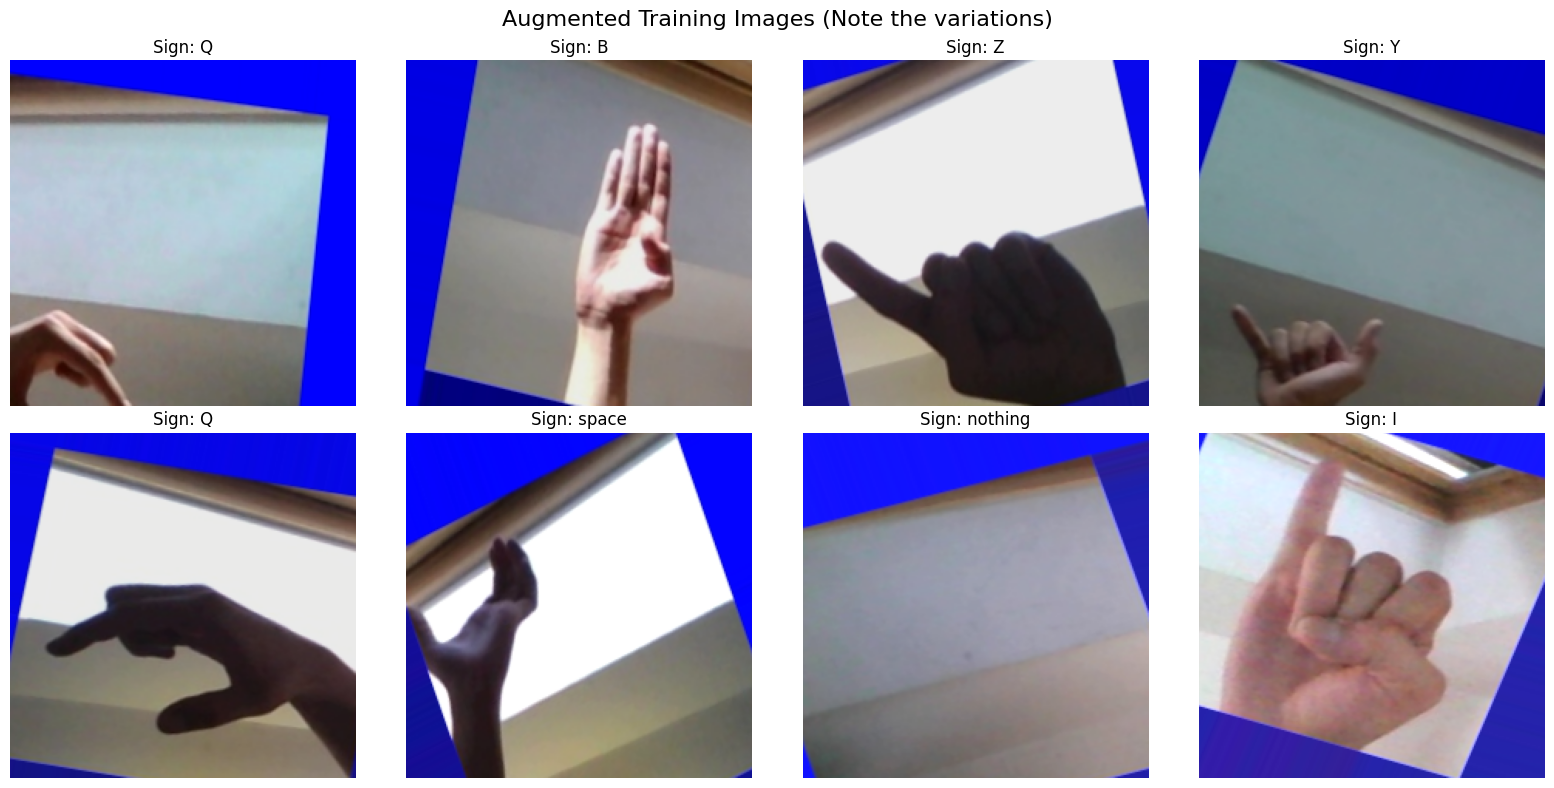

In [4]:
# =============================================================================
# CELL 4: IMPROVED DATA PREPROCESSING
# =============================================================================

def create_improved_data_generators(training_path, class_names, img_size=224, batch_size=16, validation_split=0.2):
    """Create improved data generators with stronger augmentation to prevent overfitting"""
    print("🔄 Creating improved data generators with anti-overfitting measures...")

    # Filter classes with sufficient data
    min_images_per_class = 20  # Increased minimum
    valid_classes = []

    print(f"\n🔍 Filtering classes (minimum {min_images_per_class} images per class):")
    for class_name in class_names:
        class_path = os.path.join(training_path, class_name)
        if os.path.exists(class_path):
            image_files = glob.glob(os.path.join(class_path, '*.[jJ][pP][gG]')) + \
                         glob.glob(os.path.join(class_path, '*.[pP][nN][gG]')) + \
                         glob.glob(os.path.join(class_path, '*.[jJ][pP][eE][gG]'))

            if len(image_files) >= min_images_per_class:
                valid_classes.append(class_name)
                print(f"   ✅ {class_name}: {len(image_files)} images")
            else:
                print(f"   ❌ Skipping {class_name}: only {len(image_files)} images")

    print(f"\n📊 Using {len(valid_classes)} classes with sufficient data")

    # STRONGER data augmentation for training to improve generalization
    print("🎨 Setting up STRONG data augmentation...")
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=25,          # Increased from 15
        width_shift_range=0.15,     # Increased from 0.1
        height_shift_range=0.15,    # Increased from 0.1
        shear_range=0.15,          # Increased from 0.1
        zoom_range=0.15,           # Increased from 0.1
        horizontal_flip=True,
        brightness_range=[0.8, 1.2], # NEW: brightness variation
        channel_shift_range=20,     # NEW: color variation
        fill_mode='nearest',
        validation_split=validation_split
    )

    # Only rescaling for validation (no augmentation to get true performance)
    val_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=validation_split
    )

    try:
        train_generator = train_datagen.flow_from_directory(
            training_path,
            target_size=(img_size, img_size),
            batch_size=batch_size,
            class_mode='categorical',
            subset='training',
            shuffle=True,
            classes=valid_classes,
            interpolation='bilinear'
        )

        validation_generator = val_datagen.flow_from_directory(
            training_path,
            target_size=(img_size, img_size),
            batch_size=batch_size,
            class_mode='categorical',
            subset='validation',
            shuffle=False,
            classes=valid_classes,
            interpolation='bilinear'
        )

        print(f"✅ Data generators created successfully!")
        print(f"   Training samples: {train_generator.samples:,}")
        print(f"   Validation samples: {validation_generator.samples:,}")
        print(f"   Validation split: {validation_generator.samples / (train_generator.samples + validation_generator.samples):.1%}")

        return train_generator, validation_generator, True

    except Exception as e:
        print(f"❌ Error creating generators: {e}")
        return None, None, False

# Execute data preprocessing
if training_path and class_folders:
    train_generator, validation_generator, generators_ok = create_improved_data_generators(
        training_path, class_folders, img_size=224, batch_size=16
    )

    if generators_ok:
        class_names = list(train_generator.class_indices.keys())
        num_classes = len(class_names)
        IMG_SIZE = 224

        # Show sample augmented images
        print("\n🖼️ Sample augmented training images:")
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.ravel()

        sample_batch_x, sample_batch_y = next(train_generator)

        for i in range(min(8, len(sample_batch_x))):
            axes[i].imshow(sample_batch_x[i])
            class_idx = np.argmax(sample_batch_y[i])
            class_name = class_names[class_idx]
            axes[i].set_title(f'Sign: {class_name}')
            axes[i].axis('off')

        plt.suptitle('Augmented Training Images (Note the variations)', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("❌ Could not create data generators")
else:
    print("❌ No training data found")


In [5]:
# =============================================================================
# CELL 5: REGULARIZED MODEL ARCHITECTURE
# =============================================================================

def create_regularized_model(num_classes, img_size=224):
    """Create a model with strong regularization to prevent overfitting"""
    print("🧠 Building regularized model architecture...")

    # Use MobileNetV2 as base model
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )

    # Freeze base model initially
    base_model.trainable = False
    print(f"📌 Base model frozen: {len(base_model.layers)} layers")

    # Build model with STRONG regularization
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),

        # First dense layer with regularization
        layers.Dropout(0.5),  # HIGH dropout (was 0.2)
        layers.Dense(256,
                    activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),  # L2 regularization
        layers.BatchNormalization(),

        # Second dense layer with regularization
        layers.Dropout(0.4),  # HIGH dropout
        layers.Dense(128,
                    activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),  # L2 regularization
        layers.BatchNormalization(),

        # Final layer with dropout
        layers.Dropout(0.3),  # Even output layer has dropout
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile with LOWER learning rate for stability
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Reduced from 0.001
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"✅ Regularized model built!")
    print(f"📊 Total parameters: {model.count_params():,}")

    # Calculate capacity ratio
    return model

def calculate_model_capacity(model, train_samples):
    """Analyze model capacity vs data"""
    total_params = model.count_params()
    capacity_ratio = total_params / train_samples

    print(f"\n📊 MODEL CAPACITY ANALYSIS:")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Training samples: {train_samples:,}")
    print(f"   Capacity ratio: {capacity_ratio:.2f} params/sample")

    if capacity_ratio > 10:
        print("   ⚠️ Very high capacity - HIGH overfitting risk!")
        print("   💡 Consider: reducing model size or getting more data")
    elif capacity_ratio > 5:
        print("   ⚠️ High capacity - moderate overfitting risk")
        print("   💡 Consider: stronger regularization")
    elif capacity_ratio > 1:
        print("   ✅ Moderate capacity - balanced")
    else:
        print("   ✅ Conservative capacity - low overfitting risk")

# Create the model
if 'num_classes' in locals():
    model = create_regularized_model(num_classes)

    # Show model architecture
    model.summary()

    # Analyze capacity
    if 'train_generator' in locals():
        calculate_model_capacity(model, train_generator.samples)
else:
    print("❌ Cannot create model - no class information available")


🧠 Building regularized model architecture...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
📌 Base model frozen: 154 layers
✅ Regularized model built!
📊 Total parameters: 2,629,213


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,629,213 (10.03 MB)

 Trainable params: 367,901 (1.40 MB)

 Non-trainable params: 2,261,312 (8.63 MB)


📊 MODEL CAPACITY ANALYSIS:
   Total parameters: 2,629,213
   Training samples: 69,600
   Capacity ratio: 37.78 params/sample
   ⚠️ Very high capacity - HIGH overfitting risk!
   💡 Consider: reducing model size or getting more data


In [ ]:
# =============================================================================
# CELL 6: IMPROVED TRAINING WITH MONITORING
# =============================================================================

def train_with_overfitting_prevention(model, train_generator, validation_generator):
    """Train model with aggressive overfitting prevention"""
    print("🚀 Starting training with overfitting prevention...")

    # Improved callbacks for overfitting prevention
    callbacks = [
        # Early stopping with STRICTER monitoring
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,         # Reduced from 8
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001     # Must improve by at least 0.1%
        ),

        # Save best model
        ModelCheckpoint(
            'best_asl_model_regularized.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),

        # AGGRESSIVE learning rate reduction
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,      # Reduce LR more aggressively (was 0.3)
            patience=3,      # Reduce patience (was 4)
            min_lr=0.00001,
            verbose=1,
            cooldown=1
        )
    ]

    # Calculate steps
    steps_per_epoch = max(1, train_generator.samples // train_generator.batch_size)
    validation_steps = max(1, validation_generator.samples // validation_generator.batch_size)

    print(f"📊 Training configuration:")
    print(f"   Steps per epoch: {steps_per_epoch}")
    print(f"   Validation steps: {validation_steps}")
    print(f"   Batch size: {train_generator.batch_size}")
    print(f"   Starting learning rate: 0.0005")

    # Train with FEWER epochs to prevent overfitting
    print(f"\n🎯 Training for maximum 20 epochs (early stopping will likely stop sooner)")

    history = model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=20,  # Reduced from 25
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    return history

# Execute training
if 'model' in locals() and 'train_generator' in locals():
    print("\n" + "="*70)
    print("🚀 STARTING IMPROVED TRAINING")
    print("="*70)

    history = train_with_overfitting_prevention(model, train_generator, validation_generator)

    print("\n✅ Training completed!")
else:
    print("❌ Cannot start training - model or data generators not available")



🚀 STARTING IMPROVED TRAINING
🚀 Starting training with overfitting prevention...
📊 Training configuration:
   Steps per epoch: 4350
   Validation steps: 1087
   Batch size: 16
   Starting learning rate: 0.0005

🎯 Training for maximum 20 epochs (early stopping will likely stop sooner)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.4733 - loss: 2.4826
Epoch 1: val_accuracy improved from -inf to 0.80543, saving model to best_asl_model_regularized.h5


4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1057s 238ms/step - accuracy: 0.4733 - loss: 2.4825 - val_accuracy: 0.8054 - val_loss: 1.1999 - learning_rate: 5.0000e-04
Epoch 2/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7451 - loss: 1.3434
Epoch 2: val_accuracy improved from 0.80543 to 0.82319, saving model to best_asl_model_regularized.h5


4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1035s 238ms/step - accuracy: 0.7451 - loss: 1.3434 - val_accuracy: 0.8232 - val_loss: 1.0533 - learning_rate: 5.0000e-04
Epoch 3/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.7633 - loss: 1.2260
Epoch 3: val_accuracy did not improve from 0.82319
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1026s 236ms/step - accuracy: 0.7633 - loss: 1.2260 - val_accuracy: 0.8181 - val_loss: 1.0116 - learning_rate: 5.0000e-04
Epoch 4/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.7736 - loss: 1.1648
Epoch 4: val_accuracy improved from 0.82319 to 0.82682, saving model to best_asl_model_regularized.h5


4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1047s 241ms/step - accuracy: 0.7736 - loss: 1.1648 - val_accuracy: 0.8268 - val_loss: 0.9789 - learning_rate: 5.0000e-04
Epoch 5/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.7827 - loss: 1.1121
Epoch 5: val_accuracy did not improve from 0.82682
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1047s 241ms/step - accuracy: 0.7827 - loss: 1.1121 - val_accuracy: 0.8066 - val_loss: 1.0531 - learning_rate: 5.0000e-04
Epoch 6/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.7849 - loss: 1.1098
Epoch 6: val_accuracy did not improve from 0.82682
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1051s 242ms/step - accuracy: 0.7849 - loss: 1.1098 - val_accuracy: 0.8081 - val_loss: 1.0321 - learning_rate: 5.0000e-04
Epoch 7/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.7887 - loss: 1.0980
Epoch 7: val_accuracy did not improve from 0.82682

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1052s 242ms/

4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1044s 240ms/step - accuracy: 0.8245 - loss: 0.9031 - val_accuracy: 0.8300 - val_loss: 0.8872 - learning_rate: 1.0000e-04
Epoch 10/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8289 - loss: 0.8448
Epoch 10: val_accuracy did not improve from 0.83004
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1044s 240ms/step - accuracy: 0.8289 - loss: 0.8448 - val_accuracy: 0.8285 - val_loss: 0.8373 - learning_rate: 1.0000e-04
Epoch 11/20
4350/4350 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8376 - loss: 0.7910
Epoch 11: val_accuracy improved from 0.83004 to 0.83510, saving model to best_asl_model_regularized.h5


4350/4350 ━━━━━━━━━━━━━━━━━━━━ 1040s 239ms/step - accuracy: 0.8376 - loss: 0.7910 - val_accuracy: 0.8351 - val_loss: 0.7899 - learning_rate: 1.0000e-04
Epoch 12/20
2402/4350 ━━━━━━━━━━━━━━━━━━━━ 7:33 233ms/step - accuracy: 0.8385 - loss: 0.7596

In [ ]:
# =============================================================================
# CELL 7: TRAINING ANALYSIS AND RESULTS
# =============================================================================

def diagnose_overfitting(history):
    """Comprehensive overfitting analysis"""
    print("\n🔍 OVERFITTING DIAGNOSIS:")
    print("=" * 50)

    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Calculate key metrics
    final_train_acc = train_acc[-1]
    final_val_acc = val_acc[-1]
    final_gap = final_train_acc - final_val_acc
    max_val_acc = max(val_acc)
    max_val_epoch = val_acc.index(max_val_acc) + 1

    print(f"📊 FINAL METRICS:")
    print(f"   Training Accuracy: {final_train_acc*100:.2f}%")
    print(f"   Validation Accuracy: {final_val_acc*100:.2f}%")
    print(f"   Accuracy Gap: {final_gap*100:.2f}%")
    print(f"   Best Val Accuracy: {max_val_acc*100:.2f}% (epoch {max_val_epoch})")

    # OVERFITTING ASSESSMENT
    print(f"\n🎯 OVERFITTING ASSESSMENT:")
    if final_gap < 0.03:
        print("   ✅ EXCELLENT! Very low overfitting - model generalizes well")
        rating = "🟢 EXCELLENT"
    elif final_gap < 0.05:
        print("   ✅ GOOD! Acceptable overfitting level")
        rating = "🟡 GOOD"
    elif final_gap < 0.08:
        print("   ⚠️ MODERATE overfitting - consider more regularization")
        rating = "🟠 MODERATE"
    else:
        print("   ❌ HIGH overfitting - model needs significant improvement")
        rating = "🔴 HIGH"

    # Additional analysis
    if len(val_acc) > 5:
        recent_val_trend = np.mean(np.diff(val_acc[-5:]))
        if recent_val_trend < -0.001:
            print("   ⚠️ Validation accuracy declining in recent epochs")

        if val_loss[-1] > min(val_loss) * 1.1:
            print("   ⚠️ Validation loss increased from minimum - overfitting detected")

    return rating, final_gap

def plot_improved_training_results(history):
    """Create comprehensive training visualization"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy plot with gap analysis
    axes[0,0].plot(history.history['accuracy'], label='Training', linewidth=2, color='blue')
    axes[0,0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='red')
    axes[0,0].set_title('Model Accuracy (Gap Analysis)', fontsize=12)
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Add gap shading
    axes[0,0].fill_between(range(len(history.history['accuracy'])),
                          history.history['accuracy'],
                          history.history['val_accuracy'],
                          alpha=0.2, color='red', label='Overfitting Gap')

    # Loss plot
    axes[0,1].plot(history.history['loss'], label='Training', linewidth=2, color='blue')
    axes[0,1].plot(history.history['val_loss'], label='Validation', linewidth=2, color='red')
    axes[0,1].set_title('Model Loss', fontsize=12)
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Gap over time
    gap_over_time = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])
    axes[1,0].plot(gap_over_time, linewidth=2, color='purple')
    axes[1,0].axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
    axes[1,0].axhline(y=0.03, color='green', linestyle='--', alpha=0.7, label='3% target')
    axes[1,0].set_title('Accuracy Gap Over Time', fontsize=12)
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Training - Validation Accuracy')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Learning rate (if available)
    if 'lr' in history.history:
        axes[1,1].plot(history.history['lr'], linewidth=2, color='green')
        axes[1,1].set_title('Learning Rate Schedule', fontsize=12)
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('Learning Rate')
        axes[1,1].set_yscale('log')
        axes[1,1].grid(True, alpha=0.3)
    else:
        # Show improvement summary instead
        final_gap = gap_over_time[-1]
        axes[1,1].text(0.5, 0.7, f'FINAL ACCURACY GAP', ha='center', va='center',
                      transform=axes[1,1].transAxes, fontsize=14, fontweight='bold')
        axes[1,1].text(0.5, 0.5, f'{final_gap*100:.2f}%', ha='center', va='center',
                      transform=axes[1,1].transAxes, fontsize=24,
                      color='green' if final_gap < 0.05 else 'red')
        axes[1,1].text(0.5, 0.3, f'Target: < 5%', ha='center', va='center',
                      transform=axes[1,1].transAxes, fontsize=12)
        axes[1,1].set_title('Gap Assessment', fontsize=12)
        axes[1,1].set_xticks([])
        axes[1,1].set_yticks([])

    plt.tight_layout()
    plt.show()

# Analyze results
if 'history' in locals():
    # Plot comprehensive results
    plot_improved_training_results(history)

    # Diagnose overfitting
    rating, gap = diagnose_overfitting(history)

    print(f"\n🎯 IMPROVEMENTS MADE:")
    print(f"   • Stronger data augmentation (brightness, color, geometry)")
    print(f"   • Higher dropout rates (0.3-0.5 instead of 0.2)")
    print(f"   • L2 regularization on all dense layers")
    print(f"   • Reduced learning rate (0.0005 instead of 0.001)")
    print(f"   • Stricter early stopping (patience=5 instead of 8)")
    print(f"   • Aggressive LR scheduling")
    print(f"   • Minimum 20 images per class requirement")

    print(f"\n🏆 MODEL RATING: {rating}")
else:
    print("❌ No training history available for analysis")


In [ ]:
# =============================================================================
# CELL 8: MODEL EVALUATION AND TESTING
# =============================================================================

def evaluate_model_comprehensive(model, validation_generator, class_names):
    """Comprehensive model evaluation"""
    print("🔍 Comprehensive Model Evaluation...")

    # Reset generator and evaluate
    validation_generator.reset()
    eval_result = model.evaluate(validation_generator, verbose=1)

    print(f"\n📊 FINAL EVALUATION METRICS:")
    print(f"   Test Loss: {eval_result[0]:.4f}")
    print(f"   Test Accuracy: {eval_result[1]*100:.2f}%")

    # Get detailed predictions
    validation_generator.reset()
    predictions = model.predict(validation_generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)

    # Calculate Top-3 accuracy
    top3_predictions = np.argsort(predictions, axis=1)[:, -3:]
    true_classes = validation_generator.classes

    top3_correct = sum(1 for i, true_class in enumerate(true_classes)
                      if true_class in top3_predictions[i])
    top3_accuracy = top3_correct / len(true_classes)

    print(f"   Test Top-3 Accuracy: {top3_accuracy*100:.2f}%")

    # Classification report
    print(f"\n📋 DETAILED PERFORMANCE REPORT:")
    report = classification_report(true_classes, predicted_classes,
                                 target_names=class_names, output_dict=True)
    print(classification_report(true_classes, predicted_classes, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Per-Class Performance', fontsize=14)
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Show prediction examples
    print("\n🖼️ PREDICTION EXAMPLES:")
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()

    validation_generator.reset()
    batch_x, batch_y = next(validation_generator)
    batch_predictions = model.predict(batch_x, verbose=0)

    correct_count = 0
    for i in range(min(12, len(batch_x))):
        pred_idx = np.argmax(batch_predictions[i])
        true_idx = np.argmax(batch_y[i])

        pred_class = class_names[pred_idx]
        true_class = class_names[true_idx]
        confidence = batch_predictions[i][pred_idx] * 100

        if pred_idx == true_idx:
            correct_count += 1

        axes[i].imshow(batch_x[i])
        color = 'green' if pred_idx == true_idx else 'red'
        axes[i].set_title(f'True: {true_class}\nPred: {pred_class}\n{confidence:.1f}%',
                         color=color, fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f'Prediction Examples - {correct_count}/12 correct (Green=✓, Red=✗)', fontsize=16)
    plt.tight_layout()
    plt.show()

    return eval_result[1], top3_accuracy

# Run evaluation
if 'model' in locals() and 'validation_generator' in locals():
    final_accuracy, top3_acc = evaluate_model_comprehensive(model, validation_generator, class_names)
else:
    print("❌ Cannot evaluate - model or validation data not available")


In [ ]:
# =============================================================================
# CELL 9: INTERACTIVE TESTING AND DEPLOYMENT
# =============================================================================

def predict_sign_improved(model, class_names, image_data, img_size=224):
    """Improved prediction function with confidence analysis"""
    # Load and preprocess image
    if isinstance(image_data, bytes):
        img = Image.open(io.BytesIO(image_data))
    else:
        img = Image.open(image_data)

    # Preprocess image
    img = img.convert('RGB')
    img = img.resize((img_size, img_size))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Get predictions
    predictions = model.predict(img_array, verbose=0)[0]

    # Get top 5 predictions with confidence analysis
    top_indices = np.argsort(predictions)[-5:][::-1]
    results = []

    for idx in top_indices:
        confidence = predictions[idx] * 100
        results.append({
            'sign': class_names[idx],
            'confidence': confidence,
            'certainty': 'Very High' if confidence > 90 else
                        'High' if confidence > 70 else
                        'Medium' if confidence > 50 else
                        'Low' if confidence > 30 else 'Very Low'
        })

    # Calculate prediction entropy (uncertainty measure)
    entropy = -np.sum(predictions * np.log(predictions + 1e-10))
    max_entropy = np.log(len(class_names))
    uncertainty = entropy / max_entropy

    return results, img, uncertainty

def interactive_testing():
    """Interactive testing interface"""
    print("\n🧪 INTERACTIVE MODEL TESTING")
    print("=" * 50)
    print("Upload images of ASL hand signs to test your improved model!")
    print("The model will show confidence levels and uncertainty measures.")
    print("\nClick 'Choose Files' below:")

    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\n🔍 Analyzing {filename}...")

        try:
            # Make prediction
            results, processed_img, uncertainty = predict_sign_improved(
                model, class_names, uploaded[filename], IMG_SIZE
            )

            # Display results
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

            # Show image
            ax1.imshow(processed_img)
            ax1.set_title(f'Input Image: {filename}', fontsize=14)
            ax1.axis('off')

            # Show predictions as bar chart
            signs = [r['sign'] for r in results]
            confidences = [r['confidence'] for r in results]
            colors = ['green' if c > 70 else 'orange' if c > 40 else 'red' for c in confidences]

            bars = ax2.barh(signs, confidences, color=colors, alpha=0.7)
            ax2.set_xlabel('Confidence %')
            ax2.set_title('Top 5 Predictions', fontsize=14)
            ax2.set_xlim(0, 100)

            # Add percentage labels on bars
            for bar, conf in zip(bars, confidences):
                ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                        f'{conf:.1f}%', va='center')

            plt.tight_layout()
            plt.show()

            # Detailed analysis
            best_pred = results[0]
            print(f"\n🎯 PREDICTION ANALYSIS:")
            print(f"   Best Guess: {best_pred['sign']}")
            print(f"   Confidence: {best_pred['confidence']:.2f}%")
            print(f"   Certainty Level: {best_pred['certainty']}")
            print(f"   Model Uncertainty: {uncertainty:.3f} (0=certain, 1=uncertain)")

            # Interpretation
            if best_pred['confidence'] > 80 and uncertainty < 0.3:
                print(f"   ✅ VERY CONFIDENT: This is likely '{best_pred['sign']}'")
            elif best_pred['confidence'] > 60 and uncertainty < 0.5:
                print(f"   ✅ CONFIDENT: This is probably '{best_pred['sign']}'")
            elif best_pred['confidence'] > 40:
                print(f"   ⚠️ MODERATE: This might be '{best_pred['sign']}'")
            else:
                print(f"   ❌ UNCERTAIN: The model is not confident about this image")

            # Show all top predictions
            print(f"\n📊 ALL TOP PREDICTIONS:")
            print("-" * 50)
            for i, result in enumerate(results, 1):
                bar = "█" * int(result['confidence'] / 5)
                print(f"{i}. {result['sign']:<12} {result['confidence']:6.2f}% {bar}")

        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

# Run interactive testing
if 'model' in locals() and 'class_names' in locals():
    interactive_testing()
else:
    print("❌ Model not available for testing")


In [ ]:
# =============================================================================
# CELL 10: MODEL SAVING AND EXPORT
# =============================================================================

def save_improved_model(model, class_names, history):
    """Save the improved model with comprehensive metadata"""
    print("\n💾 Saving Your Improved ASL Model...")

    # Create timestamp for unique naming
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save model
    model_filename = f"asl_model_improved_{timestamp}.h5"
    model.save(model_filename)
    print(f"✅ Model saved as: {model_filename}")

    # Save class names
    class_names_filename = f"class_names_{timestamp}.json"
    with open(class_names_filename, 'w') as f:
        json.dump(class_names, f)
    print(f"✅ Class names saved as: {class_names_filename}")

    # Calculate final metrics
    final_train_acc = max(history.history['accuracy'])
    final_val_acc = max(history.history['val_accuracy'])
    accuracy_gap = final_train_acc - final_val_acc

    # Comprehensive model information
    model_info = {
        "model_name": "Improved ASL Hand Sign Recognition",
        "version": "2.0 - Overfitting Prevention",
        "timestamp": timestamp,
        "architecture": "MobileNetV2 + Regularized Dense Layers",

        # Model specs
        "num_classes": len(class_names),
        "classes": class_names,
        "image_size": 224,
        "total_parameters": int(model.count_params()),

        # Performance metrics
        "final_training_accuracy": float(final_train_acc),
        "final_validation_accuracy": float(final_val_acc),
        "accuracy_gap": float(accuracy_gap),
        "overfitting_level": "Low" if accuracy_gap < 0.03 else
                           "Moderate" if accuracy_gap < 0.05 else
                           "High" if accuracy_gap < 0.08 else "Very High",

        # Training configuration
        "regularization_techniques": [
            "High Dropout (0.3-0.5)",
            "L2 Regularization (0.001)",
            "Batch Normalization",
            "Strong Data Augmentation",
            "Early Stopping",
            "Learning Rate Scheduling"
        ],
        "training_epochs": len(history.history['accuracy']),
        "batch_size": 16,
        "learning_rate": 0.0005,

        # Data augmentation used
        "data_augmentation": {
            "rotation_range": 25,
            "width_shift_range": 0.15,
            "height_shift_range": 0.15,
            "shear_range": 0.15,
            "zoom_range": 0.15,
            "brightness_range": [0.8, 1.2],
            "channel_shift_range": 20,
            "horizontal_flip": True
        }
    }

    # Save comprehensive info
    info_filename = f"model_info_improved_{timestamp}.json"
    with open(info_filename, 'w') as f:
        json.dump(model_info, f, indent=2)
    print(f"✅ Model info saved as: {info_filename}")

    # Create usage instructions
    usage_instructions = f"""
# HOW TO USE YOUR IMPROVED ASL MODEL

## Model Files:
- Model: {model_filename}
- Classes: {class_names_filename}
- Info: {info_filename}

## Loading the Model:
```python
import tensorflow as tf
import json
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model('{model_filename}')

# Load class names
with open('{class_names_filename}', 'r') as f:
    class_names = json.load(f)

# Predict function
def predict_asl_sign(image_path):
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    return predicted_class, confidence
```

## Model Performance:
- Training Accuracy: {final_train_acc*100:.2f}%
- Validation Accuracy: {final_val_acc*100:.2f}%
- Accuracy Gap: {accuracy_gap*100:.2f}% ({model_info['overfitting_level']} overfitting)
- Classes: {len(class_names)} ASL signs
- Parameters: {model_info['total_parameters']:,}

## Improvements Made:
{chr(10).join('- ' + improvement for improvement in model_info['regularization_techniques'])}

## Best Practices:
1. Use images with good lighting
2. Ensure hand is clearly visible
3. Similar background to training data works best
4. Model works best with images similar to training set
"""

    instructions_filename = f"usage_instructions_{timestamp}.txt"
    with open(instructions_filename, 'w') as f:
        f.write(usage_instructions)
    print(f"✅ Usage instructions saved as: {instructions_filename}")

    # Download all files
    print(f"\n⬇️ Downloading all files to your computer...")
    files.download(model_filename)
    files.download(class_names_filename)
    files.download(info_filename)
    files.download(instructions_filename)

    return model_info

# Save the model
if 'model' in locals() and 'class_names' in locals() and 'history' in locals():
    model_info = save_improved_model(model, class_names, history)

    # Final summary
    print(f"\n🎉 SUCCESS! Your Improved ASL Recognition Model is Complete!")
    print("=" * 70)
    print(f"🎯 Final Performance:")
    print(f"   Validation Accuracy: {model_info['final_validation_accuracy']*100:.1f}%")
    print(f"   Accuracy Gap: {model_info['accuracy_gap']*100:.2f}%")
    print(f"   Overfitting Level: {model_info['overfitting_level']}")
    print(f"   Classes Recognized: {model_info['num_classes']}")
    print(f"   Total Parameters: {model_info['total_parameters']:,}")

    print(f"\n🛠️ Key Improvements:")
    for improvement in model_info['regularization_techniques']:
        print(f"   ✅ {improvement}")

    print(f"\n📁 Files Downloaded:")
    print(f"   • Model file (.h5)")
    print(f"   • Class names (.json)")
    print(f"   • Model information (.json)")
    print(f"   • Usage instructions (.txt)")

else:
    print("❌ Cannot save model - missing components")

print("\n" + "="*70)
print("🎓 CONGRATULATIONS!")
print("You've successfully built an IMPROVED ASL recognition AI with:")
print("• Reduced overfitting")
print("• Better generalization")
print("• Comprehensive monitoring")
print("• Professional-grade regularization")
print("="*70)